In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


from ciu import CIU, ciuplots
import shap
import lime

import matplotlib.pyplot as plt
import seaborn as sns
import tqdm as notebook_tqdm

import warnings
warnings.filterwarnings('ignore')

In [5]:
import matplotlib.pyplot as plt

# Set globally for all plots
plt.rcParams.update({
    "figure.figsize": (10, 6),   # width, height in inches
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})



In [ ]:
'''
url = "https://raw.githubusercontent.com/matekenya/xai-comparison/refs/heads/main/data/BreastCancer.csv"
df = pd.read_csv(url, na_values=["NA"], quotechar='"', dtype={"Id": str})
'''

df = pd.read_csv('data/BreastCancer.csv')

df = df.dropna()
df = df.drop(columns=['Id'])

X = df.iloc[:,:-1]
y = df[['Class']]

In [11]:
#Splitting the Dataset for train and test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, train_size=0.7, random_state=42)

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict_proba(X_test)

### SHAP Implementation

In [12]:
explainer = shap.Explainer(model)

shap_values = explainer(X_test)

In [13]:
# Expected value (baseline prediction)
expected_value = explainer.expected_value
print("Expected value:", expected_value)

# SHAP values (main importance scores)
if isinstance(shap_values, list):
    # Binary/Multi-class classification
    shap_values_array = shap_values[1]  # Positive class
else:
    # Regression or single output
    shap_values_array = shap_values

print("SHAP values shape:", shap_values_array.shape)

# Feature names
feature_names = X.columns.tolist() if hasattr(X, 'columns') else [f'Feature_{i}' for i in range(X.shape[1])]
print("Features:", feature_names)

# Actual feature values
feature_values = X.values if hasattr(X, 'values') else X

Expected value: [0.66338912 0.33661088]
SHAP values shape: (205, 9, 2)
Features: ['Cl.thickness', 'Cell.size', 'Cell.shape', 'Marg.adhesion', 'Epith.c.size', 'Bare.nuclei', 'Bl.cromatin', 'Normal.nucleoli', 'Mitoses']


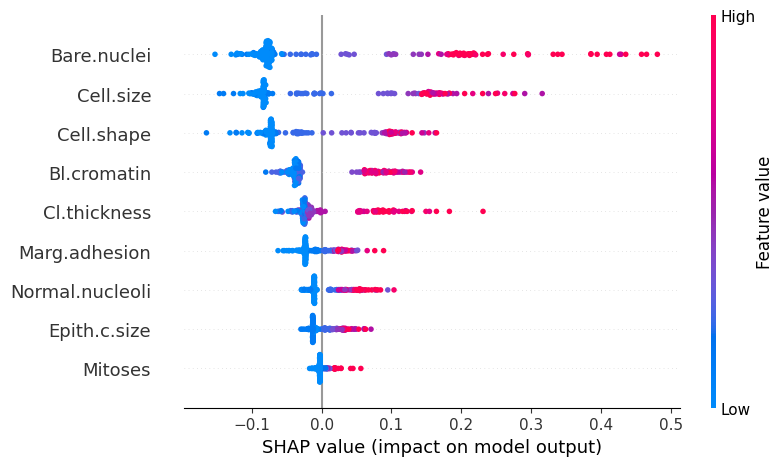

In [14]:
# Reconstruct Explanation object for class 1
shap_values_class1 = shap.Explanation(
    values=shap_values.values[:, :, 1],       # shape: (n_instances, n_features)
    base_values=shap_values.base_values[:, 1], # shape: (n_instances,)
    data=shap_values.data,                     # original feature values
    feature_names=X_test.columns.tolist()
)

shap.plots.beeswarm(shap_values_class1)

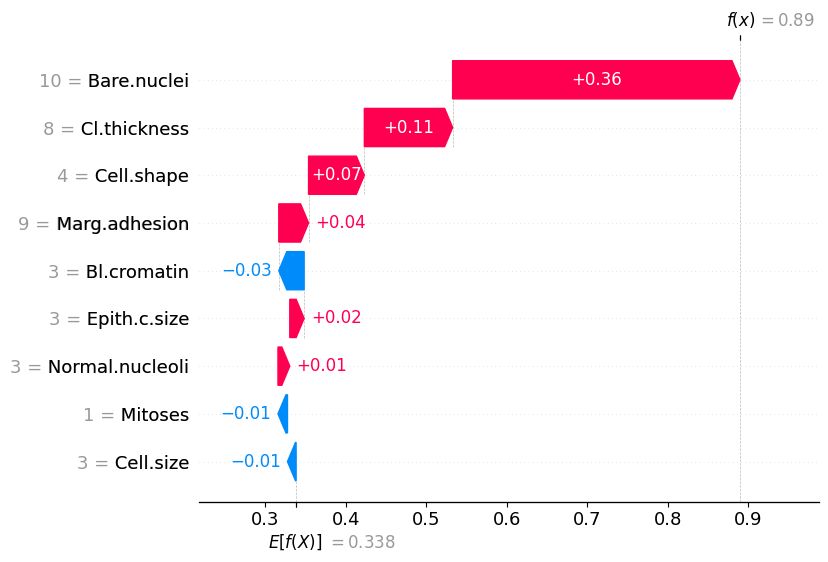

In [10]:
shap.plots.waterfall(shap_values_class1[0]) 

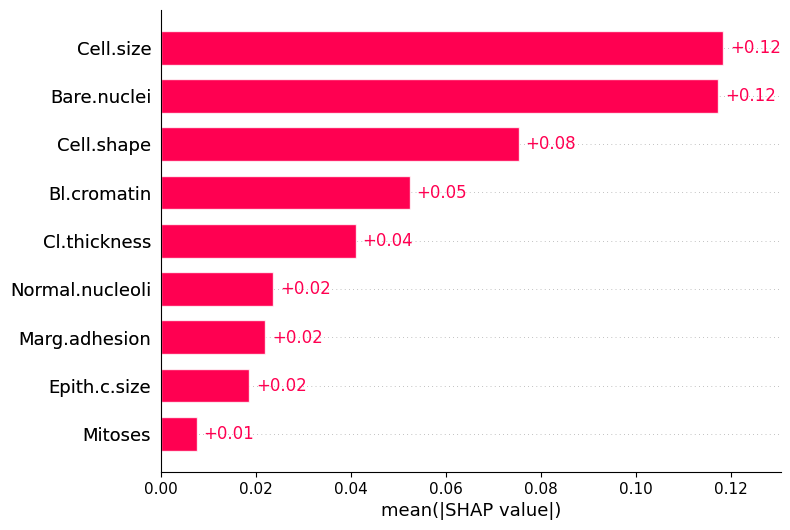

In [11]:
shap.plots.bar(shap_values_class1) 

### CIU Implementation

In [12]:
CIU_dia = CIU(model.predict_proba, ['No','Yes'], data = X_train)
CIU_dia.instance

instance_1 = X_test.iloc[[0]]
instance_2 = X_test.iloc[[1]]

print(model.predict_proba(instance_1))
print(model.predict_proba(instance_2))

[[0.11 0.89]]
[[0. 1.]]


In [13]:
instance_2

,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses
149,8,8,7,4,10,10.0,7,8,7


,CI,CU,Cinfl,outname,outval,feature,ymin,ymax,inputs,invals,neutralCU,target_concept,target_inputs
Cl.thickness,0.13,1.000000,0.065,Yes,0.89,Cl.thickness,0.76,0.89,[0],[8.0],0.5,None,None
Cell.size,0.26,0.692308,0.050,Yes,0.89,Cell.size,0.71,0.97,[1],[3.0],0.5,None,None
Cell.shape,0.13,0.769231,0.035,Yes,0.89,Cell.shape,0.79,0.92,[2],[4.0],0.5,None,None
Marg.adhesion,0.07,0.714286,0.015,Yes,0.89,Marg.adhesion,0.84,0.91,[3],[9.0],0.5,None,None
Epith.c.size,0.06,0.833333,0.020,Yes,0.89,Epith.c.size,0.84,0.90,[4],[3.0],0.5,None,None
Bare.nuclei,0.49,1.000000,0.245,Yes,0.89,Bare.nuclei,0.40,0.89,[5],[10.0],0.5,None,None
Bl.cromatin,0.10,0.600000,0.010,Yes,0.89,Bl.cromatin,0.83,0.93,[6],[3.0],0.5,None,None
Normal.nucleoli,0.09,0.555556,0.005,Yes,0.89,Normal.nucleoli,0.84,0.93,[7],[3.0],0.5,None,None
Mitoses,0.05,0.000000,-0.025,Yes,0.89,Mitoses,0.89,0.94,[8],[1.0],0.5,None,None


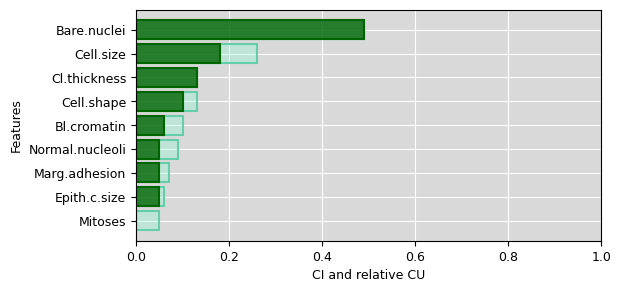

In [14]:
CIUres_1 = CIU_dia.explain(instance_1, output_inds=1)
display(CIUres_1)

p = CIU_dia.plot_ciu(CIUres_1, plot_mode="overlap", figsize=(6,3))

,CI,CU,Cinfl,outname,outval,feature,ymin,ymax,inputs,invals,neutralCU,target_concept,target_inputs
Cl.thickness,0.01,1.0,0.005,Yes,1.0,Cl.thickness,0.99,1.0,[0],[8.0],0.5,None,None
Cell.size,0.08,1.0,0.040,Yes,1.0,Cell.size,0.92,1.0,[1],[8.0],0.5,None,None
Cell.shape,0.17,1.0,0.085,Yes,1.0,Cell.shape,0.83,1.0,[2],[7.0],0.5,None,None
Marg.adhesion,0.02,1.0,0.010,Yes,1.0,Marg.adhesion,0.98,1.0,[3],[4.0],0.5,None,None
Epith.c.size,0.02,1.0,0.010,Yes,1.0,Epith.c.size,0.98,1.0,[4],[10.0],0.5,None,None
Bare.nuclei,0.02,1.0,0.010,Yes,1.0,Bare.nuclei,0.98,1.0,[5],[10.0],0.5,None,None
Bl.cromatin,0.04,1.0,0.020,Yes,1.0,Bl.cromatin,0.96,1.0,[6],[7.0],0.5,None,None
Normal.nucleoli,0.02,1.0,0.010,Yes,1.0,Normal.nucleoli,0.98,1.0,[7],[8.0],0.5,None,None
Mitoses,0.01,1.0,0.005,Yes,1.0,Mitoses,0.99,1.0,[8],[7.0],0.5,None,None


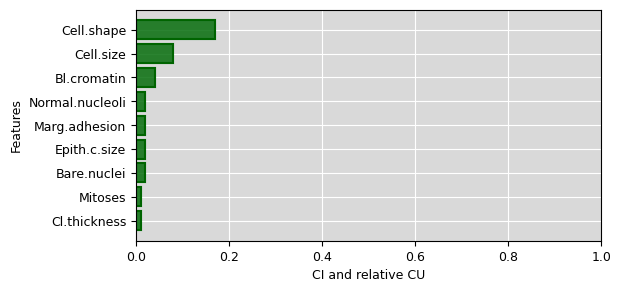

In [15]:
CIUres_2 = CIU_dia.explain(instance_2, output_inds=1)
display(CIUres_2)

p = CIU_dia.plot_ciu(CIUres_2, plot_mode="overlap", figsize=(6,3))

In [16]:
CIUres = CIU_dia.explain_all(X_test, output_inds=1, do_norm_invals=True)

In [17]:
CIUres

,CI,CU,Cinfl,outname,outval,feature,ymin,ymax,inputs,invals,neutralCU,target_concept,target_inputs,instance_name,norm_invals
0,0.13,1.000000,0.065,Yes,0.89,Cl.thickness,0.76,0.89,[0],[8.0],0.5,None,None,304,0.777778
1,0.26,0.692308,0.050,Yes,0.89,Cell.size,0.71,0.97,[1],[3.0],0.5,None,None,304,0.222222
2,0.13,0.769231,0.035,Yes,0.89,Cell.shape,0.79,0.92,[2],[4.0],0.5,None,None,304,0.333333
3,0.07,0.714286,0.015,Yes,0.89,Marg.adhesion,0.84,0.91,[3],[9.0],0.5,None,None,304,0.888889
4,0.06,0.833333,0.020,Yes,0.89,Epith.c.size,0.84,0.90,[4],[3.0],0.5,None,None,304,0.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1840,0.03,0.000000,-0.015,Yes,0.00,Epith.c.size,0.00,0.03,[4],[2.0],0.5,None,None,572,0.111111
1841,0.52,0.000000,-0.260,Yes,0.00,Bare.nuclei,0.00,0.52,[5],[1.0],0.5,None,None,572,0.0
1842,0.03,0.000000,-0.015,Yes,0.00,Bl.cromatin,0.00,0.03,[6],[2.0],0.5,None,None,572,0.111111
1843,0.16,0.000000,-0.080,Yes,0.00,Normal.nucleoli,0.00,0.16,[7],[1.0],0.5,None,None,572,0.0


In [18]:
fig = ciuplots.ciu_beeswarm(CIUres,xcol='Cinfl',  legend_title='Value scale')
fig.update_layout(height=600, width=900, margin=dict(l=20, r=20, t=50, b=20))
fig.update_layout(
    title='CInfl versus input value for all features',
    xaxis=dict(title='Contextual Influence (CInf)'),
    yaxis=dict(title='Feature'),
)
fig.show()

In [19]:
fig = ciuplots.ciu_beeswarm(CIUres,  legend_title='Value scale')
fig.update_layout(height=600, width=900, margin=dict(l=20, r=20, t=50, b=20))
fig.update_layout(
    title='CI versus input value for all features',
    xaxis=dict(title='Contextual Importance (CI)'),
    yaxis=dict(title='Feature'),
)
fig.show()

In [20]:
fig = ciuplots.ciu_beeswarm(CIUres, xcol='CU', legend_title='Value scale')
fig.update_layout(height=600, width=900, margin=dict(l=20, r=20, t=20, b=20), xaxis=dict(title='Contextual Utility (CU)'))
fig.show()

In [21]:
from ciu.CIU import contrastive_ciu

In [22]:
contrastive = contrastive_ciu(CIUres_1, CIUres_2)
display(contrastive)

Cl.thickness       0.00
Cell.size         -0.08
Cell.shape        -0.03
Marg.adhesion     -0.02
Epith.c.size      -0.01
Bare.nuclei        0.00
Bl.cromatin       -0.04
Normal.nucleoli   -0.04
Mitoses           -0.05
dtype: float64

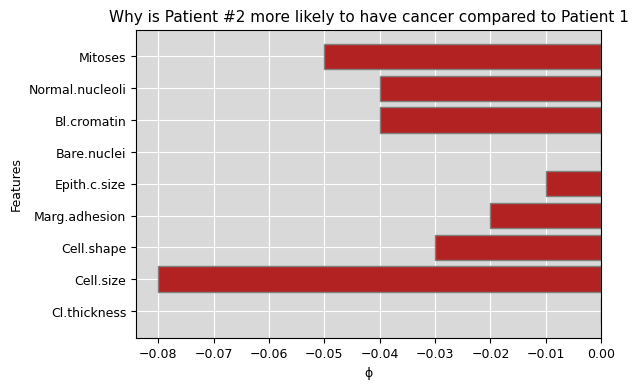

In [23]:
ciuplots.plot_contrastive(CIUres_1, CIUres_2, main="Why is Patient #2 more likely to have cancer compared to Patient 1")